In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib
from scipy import sparse
import random
from math import sqrt, log
from numpy.linalg import norm, eigh
import pprint
import itertools
import pandas as pd
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns  # Optional, it improves the aesthetics of plots
import json
import os
import re
import generator as g
import utils as u
import lowRank as lr
from scipy.linalg import sqrtm
import pandas as pd

from scipy.stats import linregress
from matplotlib.lines import Line2D

### Results of Experiment 1: Selecting vs Not

In [249]:
def parse_exp1():
    df_exp1s = []
    directory_path = 'exps/exp1'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.int64\((\d+)\)', r'\1', text)
    
            text = text.replace('\\\\', '\\')
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            match = re.search(r'_(\d+)\.out$', filename)
            df["file_index"] = int(match.group(1))
            df_exp1s.append(df)
    df1 = pd.concat(df_exp1s, ignore_index=True)
    df1 = df1.sort_values(by='file_index', ascending=True)
    df1 = df1.reset_index()
    df1.loc[450:(450+449), 'rate'] = r'$n^{1/2}\log(n)^{-1/2}$'
    df1.loc[900:(900+449), 'rate'] = r'$n^{1/2}\log(n)$'
    df1 = df1.drop(["index", "file_index"], axis=1)
    return df1

def exp1plot():
    df1 = parse_exp1()
    m = 10
    df1['sdp_error'] = df1['sdp_error'] / m
    df1['gl_error'] = df1['gl_error'] / m
    
    # Melt the dataframe to long format for plotting
    df_melted = df1.melt(id_vars=['n', 'rate', 'mu'], 
                        value_vars=['sdp_error', 'gl_error'], 
                        var_name='method', value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'sdp_error': 'SDP', 'gl_error': 'Group Lasso'})
    df_melted[r'$\mu$-rate'] = df_melted['rate']
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue=r'$\mu$-rate', style='method', markers=True, dashes=True, markersize=10)
    
    # plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel('Sample Size (n)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    plt.legend(title=r'$\mu$-Rate / Method', title_fontsize=15, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp1plot.png", dpi=300)
    plt.show()

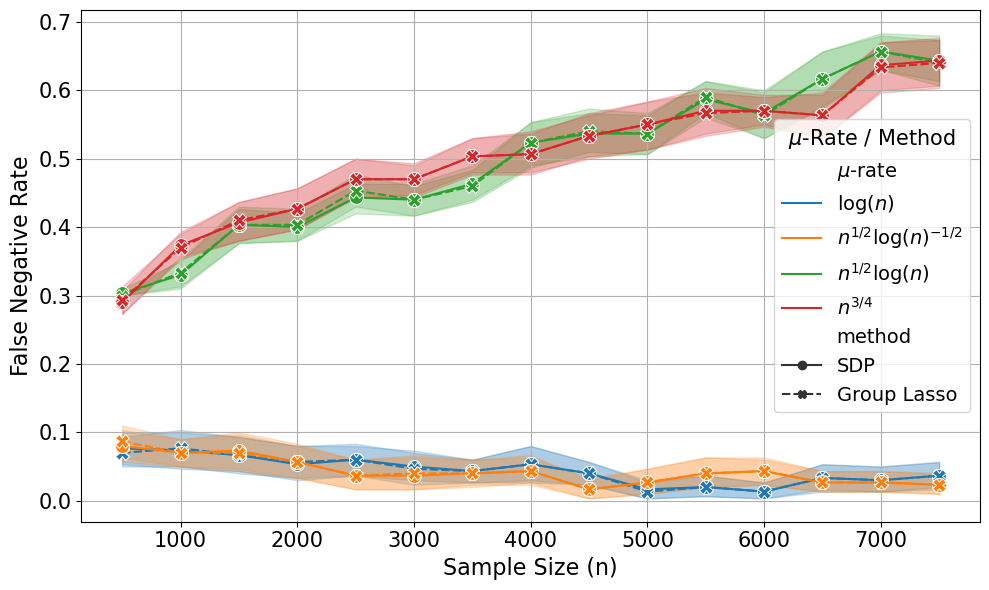

In [251]:
exp1plot()

### Results of Experiment 2: Failure of Group Lasso

In [253]:
def parse_exp2():
    df_exp2s = []
    directory_path = 'exp2_2'
    # exps/exp2: C=3; exp2: C=2; exp2_2 C=2.5
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.int64\((\d+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exp2s.append(df)
    df2 = pd.concat(df_exp2s, ignore_index=True)
    return df2

def exp2plot():
    df2 = parse_exp2()
    df2['sdp_error'] = df2['sdp_error'] / df2['m']
    df2['gl_error'] = df2['gl_error'] / df2['m']
    
    # Melt the dataframe to long format for plotting
    df_melted = df2.melt(id_vars=['n', 'm'], 
                        value_vars=['sdp_error', 'gl_error'], 
                        var_name='method', value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'sdp_error': 'SDP', 'gl_error': 'Group Lasso'})
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue='method', marker="o", markersize=8)
    plt.xscale("log")
    xticks = [400, 800, 1600, 3200, 6400]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=12)
    
    # plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel(f'Sample Size (n, log scale)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    plt.legend(title='Method', title_fontsize=15, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp2plot.png", dpi=300)
    plt.show()

In [41]:
df2 = parse_exp2()
df2['sdp_error'] = df2['sdp_error'] / df2['m']
df2['gl_error'] = df2['gl_error'] / df2['m']
# Group by sample size and compute mean and std for each method
grouped_stats = df2.groupby('n').agg(
    SDP_Avg=('sdp_error', 'mean'),
    SDP_Std=('sdp_error', 'std'),
    GL_Avg=('gl_error', 'mean'),
    GL_Std=('gl_error', 'std')
).reset_index()

# Rename for clarity
grouped_stats.columns = [
    'Sample Size (n)',
    'SDP Average FNR', 'SDP Std Dev',
    'Group Lasso Average FNR', 'Group Lasso Std Dev'
]

grouped_stats

,Sample Size (n),SDP Average FNR,SDP Std Dev,Group Lasso Average FNR,Group Lasso Std Dev
0,200,0.0,0.0,0.152381,0.026417
1,700,0.0,0.0,0.158333,0.021829
2,1200,0.0,0.0,0.167633,0.016005
3,1700,0.0,0.0,0.178862,0.013713
4,2200,0.0,0.0,0.179570,0.012030
5,2700,0.0,0.0,0.178641,0.010388
6,3200,0.0,0.0,0.181416,0.008618
7,3700,0.0,0.0,0.182920,0.010573
8,4200,0.0,0.0,0.183979,0.007032
9,4700,0.0,0.0,0.184915,0.009456


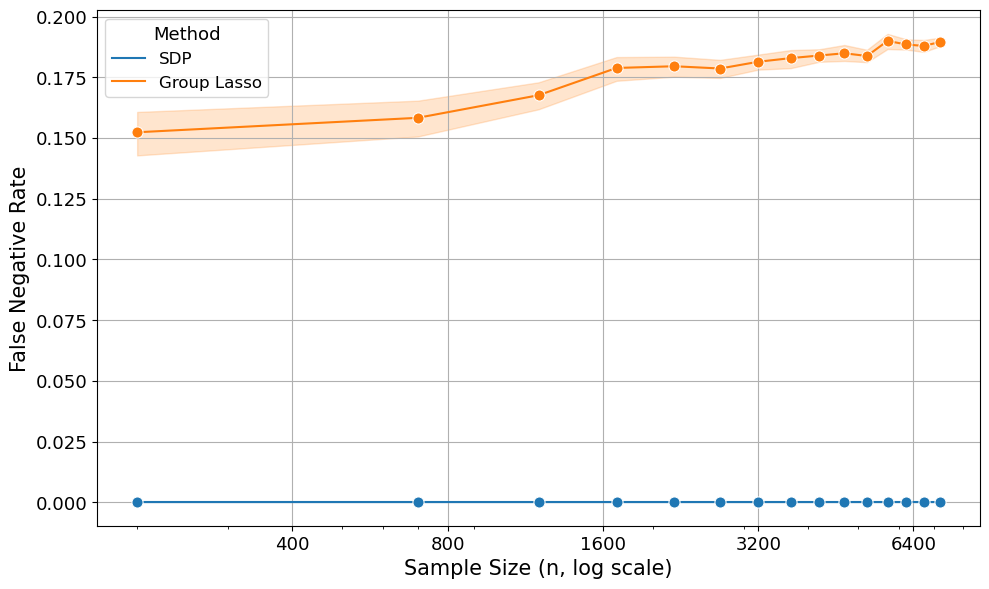

In [7]:
exp2plot()

### Results of Experiment 3: Multiple vs Single

In [255]:
def parse_exp3():
    df_exp3s = []
    directory_path = 'exps/exp3'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.int64\((\d+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exp3s.append(df)
    df3 = pd.concat(df_exp3s, ignore_index=True)
    return df3

def exp3plot():
    df = parse_exp3()
    df['single_error'] = df['single_error'] / df['m']
    df['multiple_error'] = df['multiple_error'] / df['m']
    
    # Melt the dataframe to long format for plotting
    df_melted = df.melt(id_vars=['n', 'm'], 
                        value_vars=['single_error', 
                                    'multiple_error'], 
                        var_name='method', 
                        value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'single_error': 'Single', 'multiple_error': 'Multiple'})
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue='method', marker='o', markersize=8)
    plt.xscale("log")
    xticks = [400, 800, 1600, 3200, 6400]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=14)

    #plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel(f'Sample Size (n, log scale)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    plt.legend(title='Type', title_fontsize=15, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp3plot.png", dpi=300)
    plt.show()

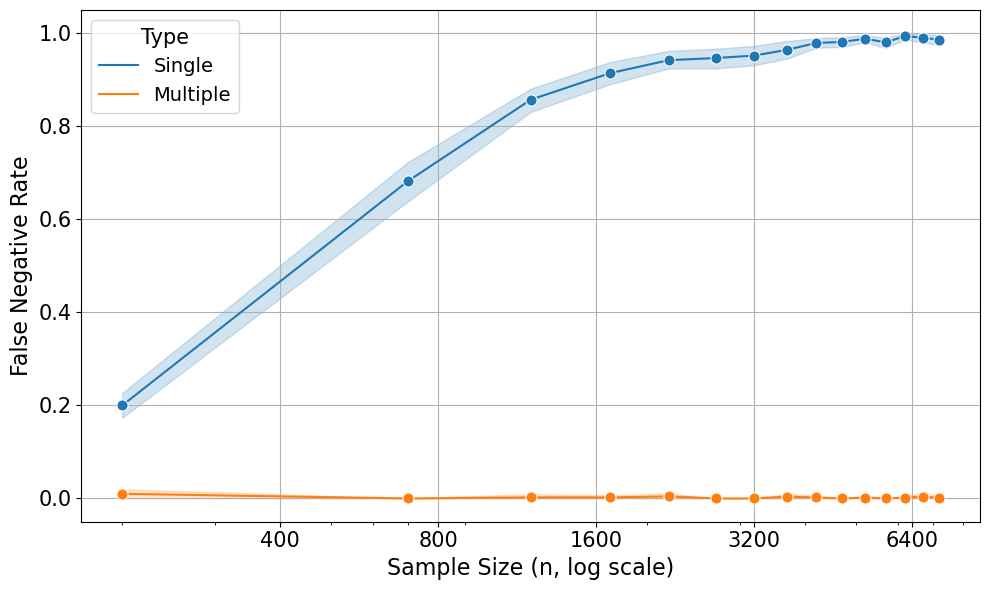

In [257]:
exp3plot()

### Results of Experiment 4: Heavy-tailed

In [259]:
def parse_exp4():
    df_exps = []
    directory_path = 'exps/exp4'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.int64\((\d+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp4plot():
    df = parse_exp4()
    df['sdp_error'] = df['sdp_error'] / df['m']
    df['trunc_error'] = df['trunc_error'] / df['m']
    
    # Melt the dataframe to long format for plotting
    df_melted = df.melt(id_vars=['n', 'm'], 
                        value_vars=['sdp_error', 
                                    'trunc_error'], 
                        var_name='method', 
                        value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'sdp_error': 'Vanilla SDP', 'trunc_error': 'Truncated SDP'})
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue='method', marker='o', markersize=8)
    plt.xscale("log")
    xticks = [400, 800, 1600, 3200, 6400]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=15)

    #plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel(f'Sample Size (n, log scale)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    plt.legend(title='Method', title_fontsize=15, fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp4plot.png", dpi=300)
    plt.show()

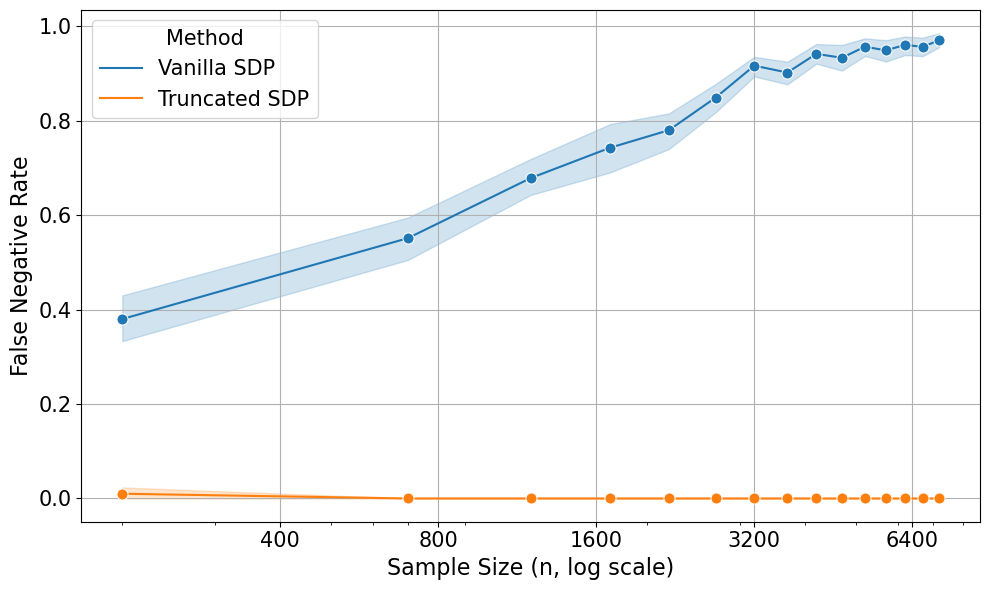

In [261]:
exp4plot()

### Results of Experiment 5: $U^\star$ and $M^\star$

In [323]:
!python get_params.py 5

In [361]:
from matplotlib.ticker import ScalarFormatter

def parse_exp5():
    df_exps = []
    directory_path = 'exp5_1_2'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            if os.path.getsize(file_path) <= 0:
                continue
            
            with open(file_path, 'r') as f:
                text = f.read()
                
            text = re.sub(r'np\.float64\(([\d\.eE+-]+)\)', r'\1', text)

            text = text.replace('\\\\', '\\')
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp5plots():
    df = parse_exp5()
    mu_rates = ['$n^{4/5}$', '$n^{5/6}$'] # sorted(df['mu_rate'].unique())
    lambda_rates = ['$2.05\\sqrt{n}$', '$3\\sqrt{n}$'] # sorted(df['lambdamin_rate'].unique())

    method_labels_u = {
        'Uhat_error': r'$U\widehat{\Psi}$',
        'Ubase_error': r'$\widehat{U}$',
        'Uspec_error': r'$\widehat{U}_{\mathrm{spec}}$'
    }
    
    method_labels_m = {
        'Mhat_error': r'$U\widehat{\Psi} \Lambda \widehat{\Psi}^\top U^\top$',
        'Mbase_error': r'$U\Lambda U^\top$',
        'Mspec_error': r'$\widehat{M}_{\mathrm{spec}}$'
    }
    u_errors = ['Uhat_error', 'Ubase_error', 'Uspec_error']

    df_u = df.melt(
        id_vars=['n', 'mu_rate', 'lambdamin_rate'],
        value_vars=u_errors,
        var_name='method',
        value_name='error'
    )

    m_errors = ['Mhat_error', 'Mbase_error', 'Mspec_error']

    m_errs = ['Mhat_error', 'Mspec_error']

    df_m = df.melt(
        id_vars=['n', 'mu_rate', 'lambdamin_rate'],
        value_vars=m_errors,
        var_name='method',
        value_name='error'
    )

    df_merr = df.melt(
        id_vars=['n', 'mu_rate', 'lambdamin_rate'],
        value_vars=m_errs,
        var_name='method',
        value_name='error'
    )

    
    df_u['method_label'] = df_u['method'].map(method_labels_u)
    df_m['method_label'] = df_m['method'].map(method_labels_m)
    df_merr['method_label'] = df_merr['method'].map(method_labels_m)

    
    n_rows = len(lambda_rates)
    n_cols = len(mu_rates)
    
    # U error matrix plot with legend in top-left subplot only
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))

    xticks = [1000, 4000, 10000, 20000, 40000]

    
    for i, lam_rate in enumerate(lambda_rates):
        for j, mu_rate in enumerate(mu_rates):
            ax = axes[i, j]
            subset = df_u[(df_u['mu_rate'] == mu_rate) & (df_u['lambdamin_rate'] == lam_rate)]
            show_legend = (i == 0 and j == 0)
            if not subset.empty:
                sns.lineplot(
                    data=subset,
                    x='n',
                    y='error',
                    hue='method_label',
                    marker='o',
                    ax=ax,
                    legend=show_legend
                )

            ax.set_title(fr'$\mu$: {mu_rate}, $\lambda^\star_{{\min}}$: {lam_rate}', fontsize=13)
            ax.set_xscale('log')
            if j == 0:
                ax.set_ylabel('Log Estimation Error', fontsize=14)
                ax.tick_params(axis='y', which='major', labelsize=13)
            if i == n_rows - 1:
                ax.set_xlabel('Sample Size (n, log scale)', fontsize=14)
                xtick_labels = [r'$10^3$', r'$4\times10^3$', r'$10^4$', r'$2\times10^4$', r'$4\times10^4$']
                ax.set_xticks(xticks)
                ax.set_xticklabels(xtick_labels, fontsize=14, rotation=25)
            ax.grid(True)

    if legend := axes[0, 0].get_legend():
        legend.set_title('Estimator', prop={'size': 13})
        for text in legend.get_texts():
            text.set_fontsize(12)
    
    #plt.suptitle(r'Subspace $\ell_{2,\infty}$-Estimation Error Plots', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.yscale("log")
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.savefig("exp5plotU.png", dpi=300)
    plt.show()
    
    # M error matrix plot with legend in top-left subplot only
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
    
    for i, lam_rate in enumerate(lambda_rates):
        for j, mu_rate in enumerate(mu_rates):
            ax = axes[i, j]
            subset = df_m[(df_m['mu_rate'] == mu_rate) & (df_m['lambdamin_rate'] == lam_rate)]
            show_legend = (i == 0 and j == 0)
            if not subset.empty:
                sns.lineplot(
                    data=subset,
                    x='n',
                    y='error',
                    hue='method_label',
                    marker='o',
                    ax=ax,
                    legend=show_legend
                )

            ax.set_title(fr'$\mu$: {mu_rate}, $\lambda^\star_{{\min}}$: {lam_rate}', fontsize=13)
            ax.set_xscale('log')
            if j == 0:
                ax.set_ylabel('Log Estimation Error', fontsize=14)
                ax.tick_params(axis='y', which='major', labelsize=13)
            if i == n_rows - 1:
                ax.set_xlabel('Sample Size (n, log scale)', fontsize=14)
                xtick_labels = [r'$10^3$', r'$4\times10^3$', r'$10^4$', r'$2\times10^4$', r'$4\times10^4$']
                ax.set_xticks(xticks)
                ax.set_xticklabels(xtick_labels, fontsize=14, rotation=25)
            ax.grid(True)
    
    if legend := axes[0, 0].get_legend():
        legend.set_title('Estimator', prop={'size': 13})
        for text in legend.get_texts():
            text.set_fontsize(12)
    
    #plt.suptitle(r'Matrix $\ell_\infty$-Estimation Error', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.yscale("log")
    
    plt.savefig('exp5plotM.png', dpi=300)
    plt.show()

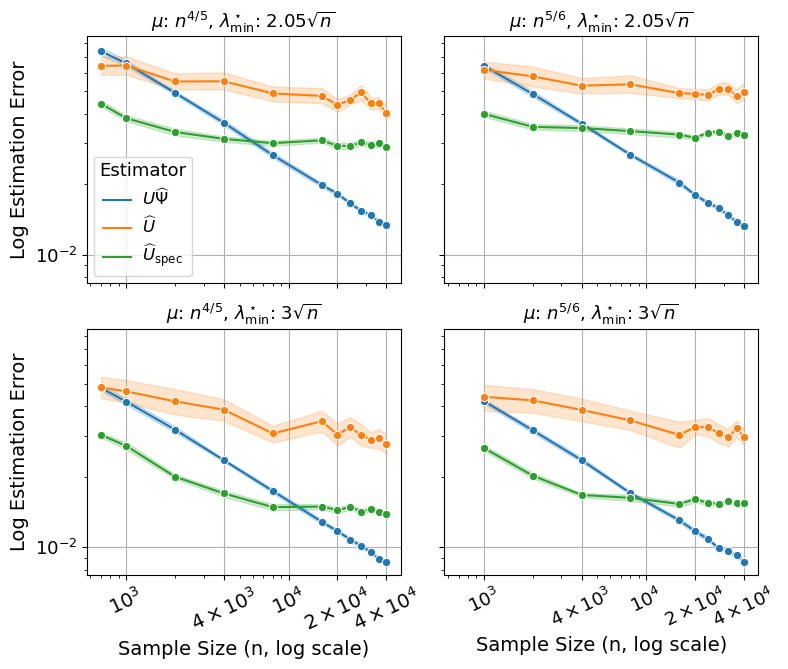

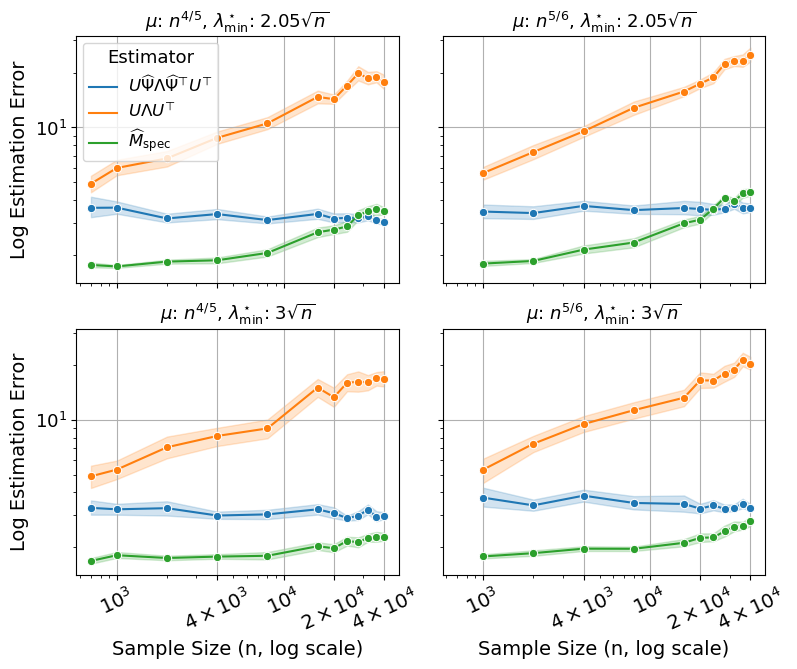

In [363]:
exp5plots()

In [7]:
import os, re, ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# ----------------------------
# Your parsing stays the same
# ----------------------------
def parse_exp5():
    df_exps = []
    directory_path = 'exp5_1_2'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):
            file_path = os.path.join(directory_path, filename)
            if os.path.getsize(file_path) <= 0:
                continue
            
            with open(file_path, 'r') as f:
                text = f.read()
                
            text = re.sub(r'np\.float64\(([\d\.eE+-]+)\)', r'\1', text)
            text = text.replace('\\\\', '\\')
            data = ast.literal_eval(text)
            df_exps.append(pd.DataFrame([data]))

    return pd.concat(df_exps, ignore_index=True)


# ----------------------------
# New: helper to make TWO 1x2 figs
# ----------------------------
def plot_two_1x2(
    df_long: pd.DataFrame,
    *,
    mu_rates,
    lambda_rates,
    ylabel: str,
    out_prefix: str,
    title_fs=15,
    label_fs=15,
    tick_fs=13,
    legend_title_fs=13,
    legend_text_fs=12,
):
    # Slight global font bump (you can tweak these)
    plt.rcParams.update({
        "font.size": tick_fs,
        "axes.titlesize": title_fs,
        "axes.labelsize": label_fs,
        "xtick.labelsize": tick_fs,
        "ytick.labelsize": tick_fs,
        "legend.fontsize": legend_text_fs,
        "legend.title_fontsize": legend_title_fs,
    })

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))

    xticks = [1000, 4000, 10000, 20000, 40000]
    xtick_labels = [r'$10^3$', r'$4\times10^3$', r'$10^4$', r'$2\times10^4$', r'$4\times10^4$']

    # Make one 1x2 figure per lambda
    for i, lam_rate in enumerate(lambda_rates):
        fig, axes = plt.subplots(
            1, len(mu_rates),
            figsize=(4 * len(mu_rates), 3.8),
            sharex=True,
            sharey=True
        )

        # If len(mu_rates)==1, axes is not a list; normalize it
        if len(mu_rates) == 1:
            axes = [axes]

        for j, mu_rate in enumerate(mu_rates):
            ax = axes[j]
            subset = df_long[(df_long["mu_rate"] == mu_rate) & (df_long["lambdamin_rate"] == lam_rate)]
            show_legend = (j == 0)  # legend only on left subplot

            if not subset.empty:
                sns.lineplot(
                    data=subset,
                    x="n",
                    y="error",
                    hue="method_label",
                    marker="o",
                    ax=ax,
                    legend=show_legend
                )

            ax.set_title(fr'$\mu$: {mu_rate}, $\lambda^\star_{{\min}}$: {lam_rate}')
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.grid(True)

            # x ticks / labels
            ax.set_xticks(xticks)
            ax.set_xticklabels(xtick_labels, rotation=25)

            if j == 0:
                ax.set_ylabel(ylabel)
                ax.set_xlabel('Sample Size ($n$, log scale)')
            else:
                ax.set_xlabel('')

            # Optional: use scalar formatter if you ever switch off log
            # ax.xaxis.set_major_formatter(formatter)

        # Tidy legend only for left axis
        if legend := axes[0].get_legend():
            legend.set_title("Estimator")
            for text in legend.get_texts():
                text.set_fontsize(legend_text_fs)

        plt.tight_layout()
        plt.savefig(f"{out_prefix}_lam{i}.png", dpi=300, bbox_inches="tight")
        plt.show()


# ----------------------------
# Your main function, refactored
# ----------------------------
def exp5plots_split():
    df = parse_exp5()

    mu_rates = ['$n^{4/5}$', '$n^{5/6}$']
    lambda_rates = ['$2.05\\sqrt{n}$', '$3\\sqrt{n}$']

    method_labels_u = {
        'Uhat_error': r'$U\widehat{\Psi}$',
        'Ubase_error': r'$\widehat{U}$',
        'Uspec_error': r'$\widehat{U}_{\mathrm{spec}}$'
    }

    method_labels_m = {
        'Mhat_error': r'$U\widehat{\Psi} \Lambda \widehat{\Psi}^\top U^\top$',
        'Mbase_error': r'$U\Lambda U^\top$',
        'Mspec_error': r'$\widehat{M}_{\mathrm{spec}}$'
    }

    # ---- U ----
    u_errors = ['Uhat_error', 'Ubase_error', 'Uspec_error']
    df_u = df.melt(
        id_vars=['n', 'mu_rate', 'lambdamin_rate'],
        value_vars=u_errors,
        var_name='method',
        value_name='error'
    )
    df_u['method_label'] = df_u['method'].map(method_labels_u)

    plot_two_1x2(
        df_u,
        mu_rates=mu_rates,
        lambda_rates=lambda_rates,
        ylabel='Log Estimation Error',
        out_prefix="exp5plotU_split",
        title_fs=15,
        label_fs=15,
        tick_fs=13,
        legend_title_fs=13,
        legend_text_fs=12,
    )

    # ---- M ----
    m_errors = ['Mhat_error', 'Mbase_error', 'Mspec_error']
    df_m = df.melt(
        id_vars=['n', 'mu_rate', 'lambdamin_rate'],
        value_vars=m_errors,
        var_name='method',
        value_name='error'
    )
    df_m['method_label'] = df_m['method'].map(method_labels_m)

    plot_two_1x2(
        df_m,
        mu_rates=mu_rates,
        lambda_rates=lambda_rates,
        ylabel='',
        out_prefix="exp5plotM_split",
        title_fs=15,
        label_fs=15,
        tick_fs=13,
        legend_title_fs=13,
        legend_text_fs=12,
    )

<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: inv

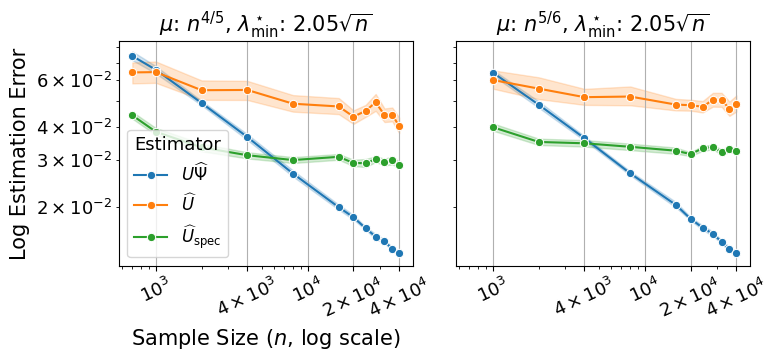

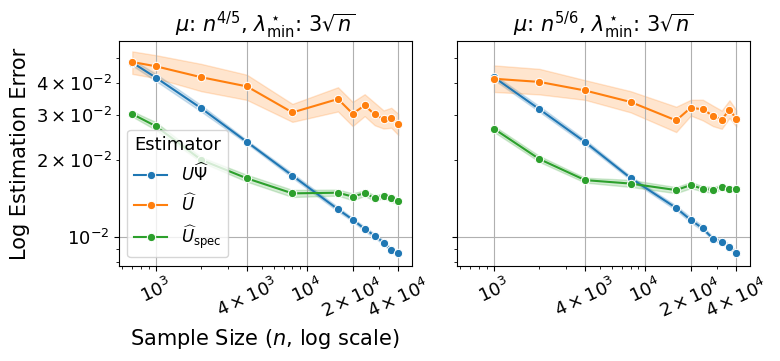

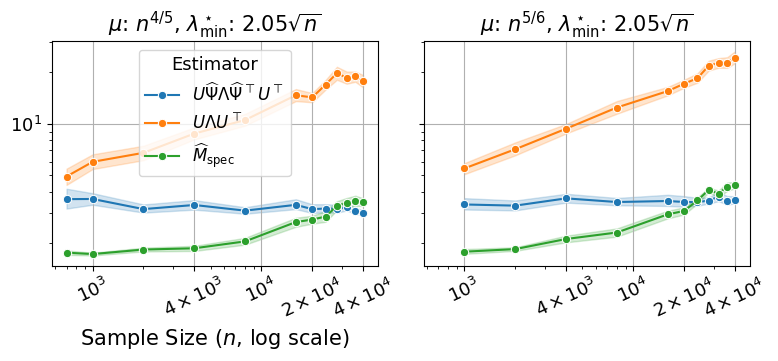

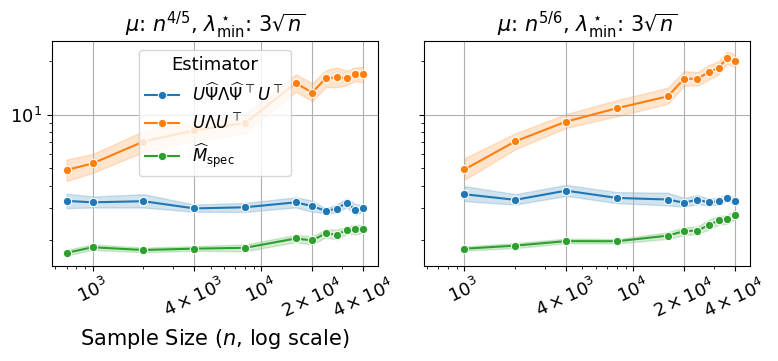

In [8]:
exp5plots_split()

### Results of Experiment 6

In [233]:
def parse_exp6():
    df_exps = []
    directory_path = 'exps/exp6'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            if os.path.getsize(file_path) <= 0:
                continue
            
            with open(file_path, 'r') as f:
                text = f.read()
                
            text = re.sub(r'np\.float64\(([\d\.eE+-]+)\)', r'\1', text)

            text = text.replace('\\\\', '\\')
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp6plot():

    df = parse_exp6()
    
    # Plot Uhat_error
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x='n', y='Uhat_error', hue='rate', marker='o', markersize=9)
    # plt.title(r'Subspace $\ell_{2,\infty}$-Estimation Error vs n', fontsize=16)
    plt.xlabel('Matrix dimension n', fontsize=20)
    plt.ylabel('Estimation Error', fontsize=20)
    plt.legend(title='Rate', title_fontsize=19, fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp6subspace.png", dpi=300)
    plt.show()
    
    # Plot Mhat_error
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x='n', y='Mhat_error', hue='rate', marker='o', markersize=8)
    # plt.title(r'Matrix $\ell_{\infty}$-Estimation Error vs n')
    plt.xlabel('Sample Size (n)', fontsize=14)
    # plt.ylabel('Estimation Error', fontsize=15)
    plt.ylabel('Estimation Error', fontsize=14)
    plt.legend(title='Rate', title_fontsize=14, fontsize=13)
    plt.grid(True)
    # plt.legend().set_visible(False)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.savefig("exp6matrix.png", dpi=300)
    plt.show()

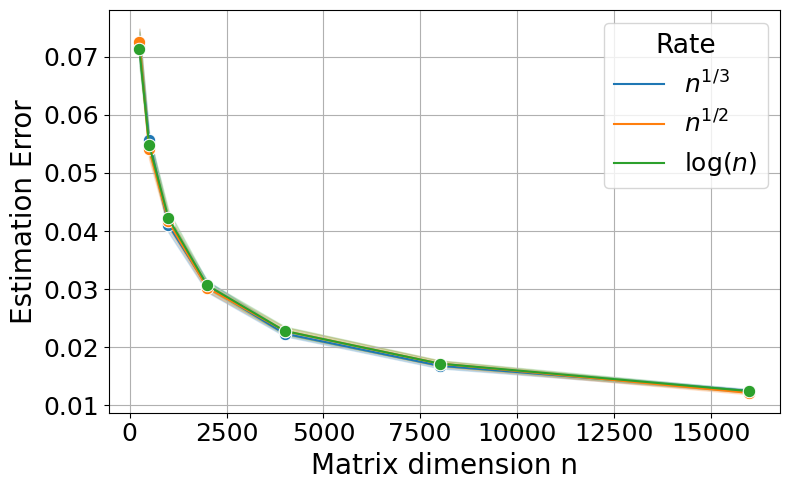

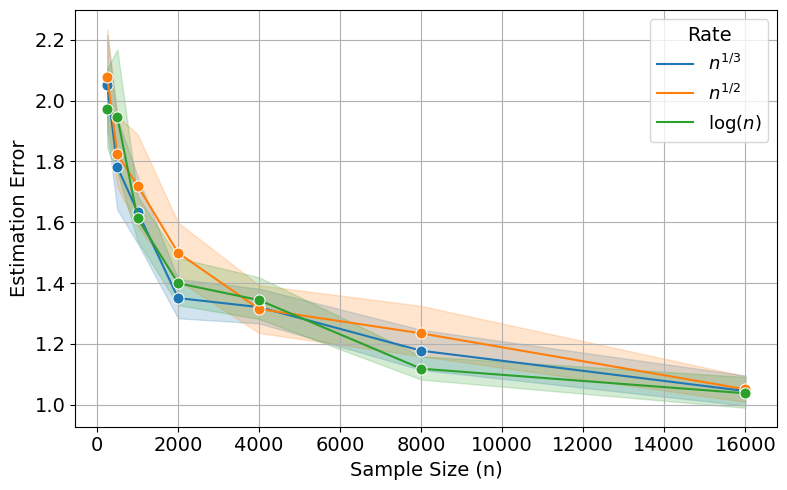

In [235]:
exp6plot()

### Results of Experiment 7: Varying Scale

In [35]:
!python get_params.py 7

In [279]:
def parse_exp7(directory_path='exps/exp7'):
    df_exps = []
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.int64\((\d+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp7plot():
    df = parse_exp7()
    df['sdp_error'] = df['sdp_error'] / df['m']
    df['gl_error'] = df['gl_error'] / df['m']
    
    # Melt the dataframe to long format for plotting
    df_melted = df.melt(id_vars=['n', 'm', 'const'], 
                        value_vars=['sdp_error', 'gl_error'], 
                        var_name='method', value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'sdp_error': 'SDP', 'gl_error': 'Group Lasso'})
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue='const', style="method", markers=True, dashes=True, markersize=8)
    plt.xscale("log")
    xticks = [400, 800, 1600, 3200]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=15)
    
    #plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel('Sample Size (n, log scale)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    #plt.legend(title='Scale / Method', title_fontsize=15, fontsize=14, framealpha=0.4)
    plt.legend(
        title='Scale / Method', 
        title_fontsize=15, 
        fontsize=14, 
        framealpha=0.4, 
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5)
    )
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp7plot.png", dpi=300)
    plt.show()

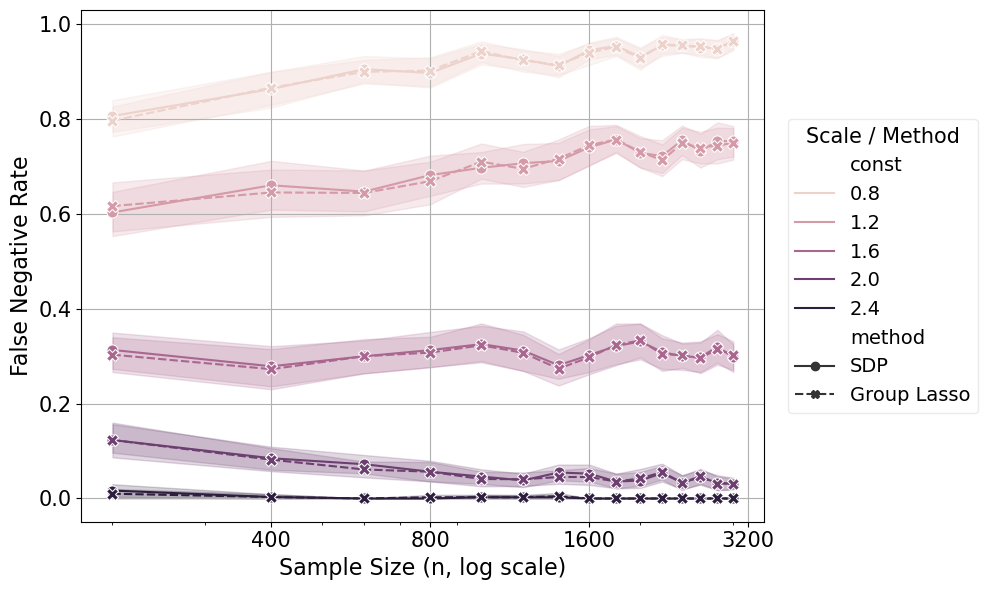

In [281]:
exp7plot()

In [275]:
def exp7plotpartial():
    df = parse_exp7("exp7_5")
    df = df[(df["const"] > 1.2) & (df["const"] < 2)]
    df['sdp_error'] = df['sdp_error'] / df['m']
    df['gl_error'] = df['gl_error'] / df['m']
    
    # Melt the dataframe to long format for plotting
    df_melted = df.melt(id_vars=['n', 'm', 'const'], 
                        value_vars=['sdp_error', 'gl_error'], 
                        var_name='method', value_name='error')
    
    # Rename method values for clarity
    df_melted['method'] = df_melted['method'].map({'sdp_error': 'SDP', 'gl_error': 'Group Lasso'})
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='n', y='error', hue='const', style="method", markers=True, dashes=True, markersize=8)
    plt.xscale("log")
    xticks = [400, 800, 1600, 3200, 6400]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=15)
    
    #plt.title('Error Rate by Sample Size and Method', fontsize=16)
    plt.xlabel('Sample Size (n, log scale)', fontsize=16)
    plt.ylabel('False Negative Rate', fontsize=16)
    #plt.legend(title='Scale / Method', title_fontsize=15, fontsize=14, framealpha=0.4)
    plt.legend(
        title='Scale / Method', 
        title_fontsize=15, 
        fontsize=14, 
        framealpha=0.4, 
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5)
    )
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp7plotpartial.png", dpi=300)
    plt.show()

In [39]:
df = parse_exp7("exp7_4")
df["n"].unique().sort()

In [45]:
60 * 1024

61440

In [40]:
df[(df["n"]==200) & (df["const"]==1.6)].shape

(30, 6)

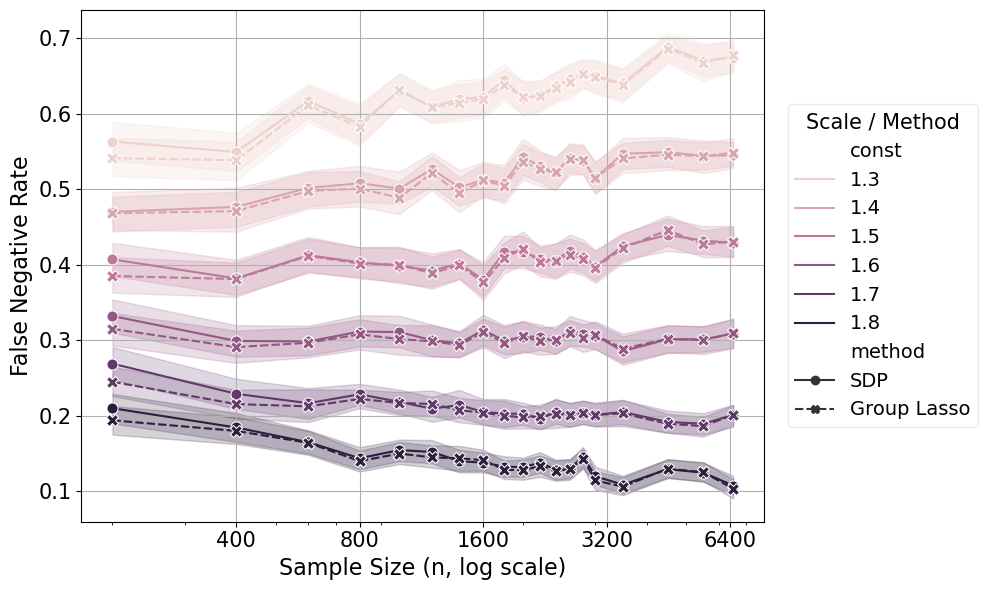

In [277]:
exp7plotpartial()

### Results of Experiment 8

In [413]:
def parse_exp8():
    df_exps = []
    directory_path = 'exp8'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.float64\(([\d\.eE+-]+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp8plot():
    df = parse_exp8()
    df_melted = df.melt(
        id_vars=['n', 'mu'],
        value_vars=["spec_error", "hat_error"],
        var_name='method',
        value_name='error'
    )
    # Rename method values for clarity
    method_labels = {
        'spec_error': r'$\widehat{M}_{\mathrm{spec}}$', 
        'hat_error': r'$U\widehat{\Psi} \Lambda \widehat{\Psi}^\top U^\top$'
    }
    df_melted['method'] = df_melted['method'].map(method_labels)

    # Prepare color palette manually
    unique_methods = df_melted['method'].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_methods))
    color_dict = dict(zip(unique_methods, palette))
    
    df_melted = df_melted.sort_values(by='mu')
    
    df_melted['is_outlier'] = False
    for method in unique_methods:
        method_mask = df_melted['method'] == method
        threshold = 100
        df_melted.loc[method_mask & (df_melted['error'] > threshold), 'is_outlier'] = True

    # Plot non-outliers
    plt.figure(figsize=(10, 6))
    for method in unique_methods:
        method_df = df_melted[(df_melted['method'] == method) & (~df_melted['is_outlier'])]
        plt.scatter(method_df['mu'], method_df['error'], alpha=0.4, s=10, label=f'{method}', 
                    color=color_dict[method])

    # Plot outliers with different style
    for method in unique_methods:
        outliers = df_melted[(df_melted['method'] == method) & (df_melted['is_outlier'])]
        plt.scatter(outliers['mu'], outliers['error'], alpha=0.9, s=20, marker='o', 
                    label=None, color=color_dict[method])
    
    log_results = {}
    for method, group in df_melted.groupby('method'):
        x_log = np.log(group['mu'])
        y_log = np.log(group['error'])
        slope, intercept, r_value, p_value, std_err = linregress(x_log, y_log)
        log_results[method] = (slope, intercept)
        
        # Optionally add the fitted line
        x_vals = np.linspace(x_log.min(), x_log.max(), 100)
        y_vals = slope * x_vals + intercept
        plt.plot(np.exp(x_vals), np.exp(y_vals), '--', color=color_dict[method],
                 label=f'{method} (slope={slope:.2f})', linewidth=2.5)

    

    legend_elements = []
    for method in unique_methods:
        color = color_dict[method]
        slope = log_results[method][0]
        
        legend_elements.extend([
            Line2D([0], [0], marker='o', linestyle='', color=color,
                   label=method, alpha=0.5, markersize=6),
            Line2D([0], [0], linestyle='--', color=color,
                   label=f'{method} (slope={slope:.2f})', linewidth=2.5)
        ])

    
    plt.legend(handles=legend_elements, title="Method", title_fontsize=13, fontsize=12)
    
    
    plt.xscale("log")
    plt.yscale("log")
    plt.tick_params(axis='both', which='major', labelsize=14)
    xticks = [200, 300, 400, 600, 1000]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=14)
    plt.xlabel(r'Incoherence parameter ($\mu$, log scale)', fontsize=15)
    plt.ylabel('Estimation Error', fontsize=15)
    # plt.legend(title='Method', title_fontsize=13, fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp8plot_with_fit.png", dpi=300)
    plt.show()

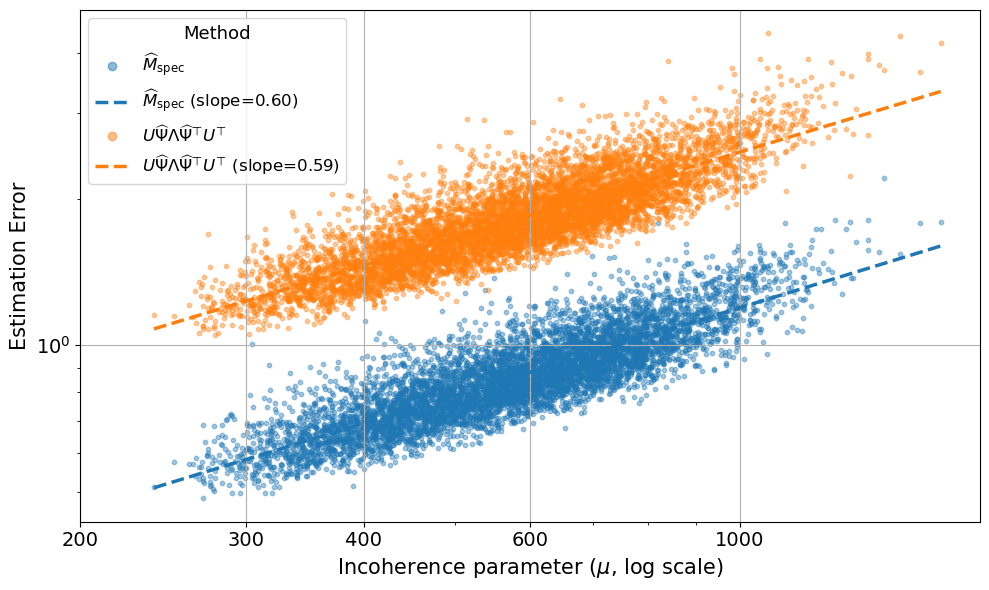

In [415]:
exp8plot()

In [433]:
def parse_exp9():
    df_exps = []
    directory_path = 'exp9'
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.out'):  # Assuming the files are text files
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as f:
                text = f.read()
            
            # Replace np.int64(...) with just the integer inside (convert to int)
            # This avoids needing to evaluate np.int64 directly
            text = re.sub(r'np\.float64\(([\d\.eE+-]+)\)', r'\1', text)
            
            # Safely evaluate the dictionary string
            data = ast.literal_eval(text)
            
            # Convert to a DataFrame with one row
            df = pd.DataFrame([data])
            df_exps.append(df)
    dfs = pd.concat(df_exps, ignore_index=True)
    return dfs

def exp9plot():
    df = parse_exp9()
    df_melted = df.melt(
        id_vars=['n', 'mu'],
        value_vars=["spec_error", "hat_error"],
        var_name='method',
        value_name='error'
    )
    # Rename method values for clarity
    method_labels = {
        'spec_error': r'$\widehat{M}_{\mathrm{spec}}$', 
        'hat_error': r'$U\widehat{\Psi} \Lambda \widehat{\Psi}^\top U^\top$'
    }
    df_melted['method'] = df_melted['method'].map(method_labels)

    # Prepare color palette manually
    unique_methods = df_melted['method'].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_methods))
    color_dict = dict(zip(unique_methods, palette))
    
    df_melted = df_melted.sort_values(by='mu')
    
    df_melted['is_outlier'] = False
    for method in unique_methods:
        method_mask = df_melted['method'] == method
        threshold = 100
        df_melted.loc[method_mask & (df_melted['error'] > threshold), 'is_outlier'] = True

    # Plot non-outliers
    plt.figure(figsize=(10, 6))
    for method in unique_methods:
        method_df = df_melted[(df_melted['method'] == method) & (~df_melted['is_outlier'])]
        plt.scatter(method_df['mu'], method_df['error'], alpha=0.4, s=10, label=f'{method}', 
                    color=color_dict[method])

    # Plot outliers with different style
    for method in unique_methods:
        outliers = df_melted[(df_melted['method'] == method) & (df_melted['is_outlier'])]
        plt.scatter(outliers['mu'], outliers['error'], alpha=0.9, s=20, marker='o', 
                    label=None, color=color_dict[method])
    
    log_results = {}
    for method, group in df_melted.groupby('method'):
        x_log = np.log(group['mu'])
        y_log = np.log(group['error'])
        slope, intercept, r_value, p_value, std_err = linregress(x_log, y_log)
        log_results[method] = (slope, intercept)
        
        # Optionally add the fitted line
        x_vals = np.linspace(x_log.min(), x_log.max(), 100)
        y_vals = slope * x_vals + intercept
        plt.plot(np.exp(x_vals), np.exp(y_vals), '--', color=color_dict[method],
                 label=f'{method} (slope={slope:.2f})', linewidth=2.5)

    

    legend_elements = []
    for method in unique_methods:
        color = color_dict[method]
        slope = log_results[method][0]
        
        legend_elements.extend([
            Line2D([0], [0], marker='o', linestyle='', color=color,
                   label=method, alpha=0.5, markersize=6),
            Line2D([0], [0], linestyle='--', color=color,
                   label=f'{method} (slope={slope:.2f})', linewidth=2.5)
        ])

    
    plt.legend(handles=legend_elements, title="Method", title_fontsize=14, fontsize=13, framealpha=0.3)
    
    
    plt.xscale("log")
    plt.yscale("log")
    plt.tick_params(axis='both', which='major', labelsize=14)
    xticks = [200, 300, 400, 600, 1000]
    plt.xticks(xticks, labels=[str(x) for x in xticks], fontsize=14)
    plt.xlabel(r'Incoherence parameter ($\mu$, log scale)', fontsize=15)
    plt.ylabel('Estimation Error', fontsize=15)
    # plt.legend(title='Method', title_fontsize=13, fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exp9plot_with_fit.png", dpi=300)
    plt.show()

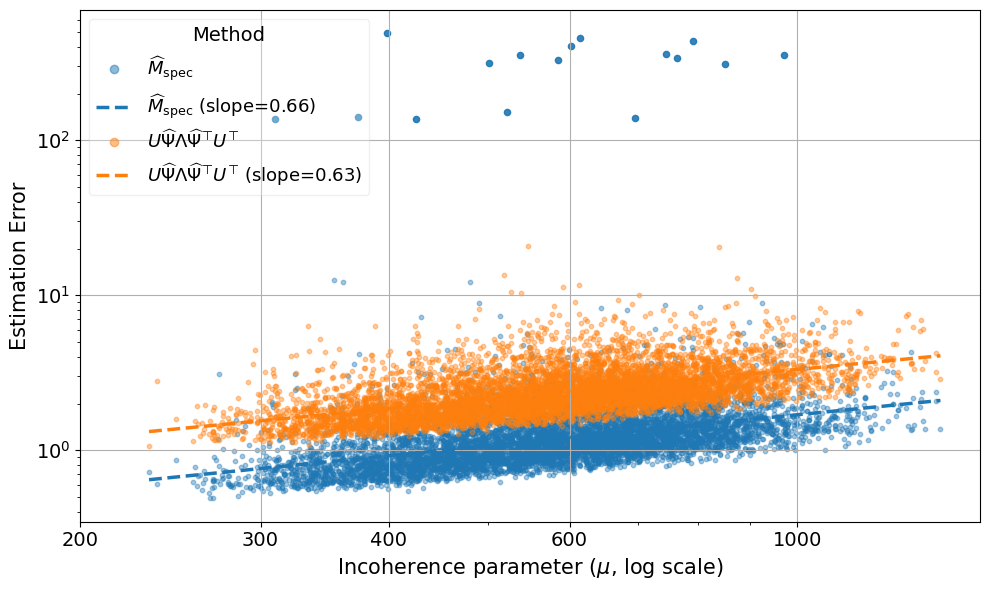

In [435]:
exp9plot()

In [283]:
from exp5 import exp5

In [293]:
n = 1000
mu = n**(5/6)
mu_rate = r"$n^{3/5}$"
lambdamin = 2.05*sqrt(n)
lambdamin_rate = r"$2.05\sqrt(n)$"
exp5(n, mu, mu_rate, lambdamin, lambdamin_rate)

{'Uhat_error': 0.0632176941840389,
 'Mhat_error': 3.1425888410696174,
 'Ubase_error': 0.061493944749975604,
 'Mbase_error': 5.522376948866086,
 'Uspec_error': 0.044861197227695236,
 'Mspec_error': 1.9599302979164968,
 'n': 1000,
 'mu': 316.227766016838,
 'mu_rate': '$n^{3/5}$',
 'lambdamin': 64.82669203345176,
 'lambdamin_rate': '$2.05\\sqrt(n)$',
 'delta': 6.907755278982137,
 'delta_rate': '$\\log(n)$',
 'r': 3}